In [1]:
import os
import pyvista as pv
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [2]:
csv_path = "/Users/chunyang/projects/particle/data/Velocity_smooth/073_final.csv"
df = pd.read_csv(csv_path)

In [5]:
print(df.head())

   Unnamed: 0.1  Unnamed: 0  particle  frame           z            y  \
0         28709           2       465      2  175.843047  1158.056826   
1         28710         202       499      2  193.181167  1172.111152   
2         28711         402       505      2  197.874409  1140.127961   
3         28712         602       510      2  199.899915  1112.163326   
4         28713         802       516      2  202.876811  1124.986777   

             x        vz        vy        vx   velMags   x_original  \
0  1194.982458  0.023299  0.005955 -0.004620  0.024616  1195.008815   
1  1183.139809  0.064378  0.000973 -0.099141  0.101003  1183.162216   
2  1188.424571  0.034669 -0.015772 -0.043114  0.059221  1188.427470   
3  1189.717830  0.039815 -0.017045  0.028483  0.049967  1189.725895   
4  1185.317594  0.023375  0.001224 -0.030147  0.064338  1185.340460   

    y_original  z_original  
0  1158.044529  175.841192  
1  1172.119135  193.164369  
2  1140.137335  197.886901  
3  1112.147930  19

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def compute_velocity_correlation(df, t0, bin_width=5, max_distance=100):
    """
    Compute velocity correlation function R(t, L) based on particle velocity data.
    R(t, L) ~ sum_{i, j with |r_i - r_j|=L} [ (v_i(t0) - v_bar(t0)) · (v_j(t1) - v_bar(t1)) ]

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'frame', 'particle', 'x', 'y', 'z', 'vx', 'vy', 'vz'
    t0 : int
        The current frame index. We use t1 = t0 - 1.
    bin_width : float
        Bin size for distance L (e.g., 5 units).
    max_distance : float
        Maximum distance to consider.

    Returns
    -------
    L_bins : np.ndarray
        The midpoints of the distance bins.
    correlations : np.ndarray
        The average velocity correlation for each bin.
    """

    t1 = t0 - 1

    # Select data for the two frames
    df_t0 = df[df["frame"] == t0].copy()
    df_t1 = df[df["frame"] == t1].copy()

    if len(df_t0) == 0 or len(df_t1) == 0:
        raise ValueError(f"No particles found for frames {t0} or {t1}.")

    # Positions and velocities
    pos_t0 = df_t0[["x", "y", "z"]].values
    vel_t0 = df_t0[["vx", "vy", "vz"]].values
    pos_t1 = df_t1[["x", "y", "z"]].values
    vel_t1 = df_t1[["vx", "vy", "vz"]].values

    # Subtract mean velocities from each frame
    mean_vel_t0 = vel_t0.mean(axis=0)
    mean_vel_t1 = vel_t1.mean(axis=0)
    vel_t0 -= mean_vel_t0
    vel_t1 -= mean_vel_t1

    # Compute pairwise distances between positions (t0 vs t1)
    dists = cdist(pos_t0, pos_t1)  # shape: (N_t0, N_t1)

    # Compute pairwise dot products of velocities
    # We'll do this by outer product: for each i, j, dot(vel_t0[i], vel_t1[j])
    # A vectorized trick is to reshape and multiply, then sum along the last axis.
    # shape(vel_t0) = (N_t0, 3), shape(vel_t1) = (N_t1, 3)
    # We can do broadcasting: (N_t0, 1, 3) * (1, N_t1, 3) -> (N_t0, N_t1, 3) -> sum over axis=2
    vel_t0_3d = vel_t0[:, np.newaxis, :]       # shape: (N_t0, 1, 3)
    vel_t1_3d = vel_t1[np.newaxis, :, :]       # shape: (1, N_t1, 3)
    dot_products = np.sum(vel_t0_3d * vel_t1_3d, axis=2)  # shape: (N_t0, N_t1)

    # Define distance bins
    bin_edges = np.arange(0, max_distance + bin_width, bin_width)
    L_bins = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # midpoints
    correlations = np.zeros_like(L_bins, dtype=float)
    counts = np.zeros_like(L_bins, dtype=int)

    # Assign each distance to a bin index
    # We'll flatten dists and dot_products, bin them, then accumulate
    flat_dists = dists.ravel()
    flat_dots = dot_products.ravel()

    # Only consider distances up to max_distance
    mask = flat_dists <= max_distance
    flat_dists = flat_dists[mask]
    flat_dots = flat_dots[mask]

    # Digitize distances to get bin indices
    bin_idx = np.digitize(flat_dists, bin_edges) - 1  # shift to 0-based

    # Accumulate sums
    for b_idx, val in zip(bin_idx, flat_dots):
        if 0 <= b_idx < len(correlations):
            correlations[b_idx] += val
            counts[b_idx] += 1

    # Avoid division by zero
    valid = counts > 0
    correlations[valid] /= counts[valid]
    # bins with zero counts remain 0

    return L_bins, correlations



In [33]:
def plot_velocity_correlations(df, t_values, bin_width=5, max_distance=50):
    """
    Compute and plot the velocity correlation function for multiple time frames.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the columns: 'frame', 'particle', 'x', 'y', 'z', 'vx', 'vy', 'vz'
    t_values : iterable of int
        List or iterable of t0 values (current frame indices) at which to compute the correlation.
        (The function uses t1 = t0 - 1 for the correlation.)
    bin_width : float, optional
        The bin size for distance L, by default 5.
    max_distance : float, optional
        The maximum distance to consider, by default 50.
    
    Returns
    -------
    None
        The function creates a plot with each t0's velocity correlation function.
    """
    # Use a professional style for the plot
    # plt.style.use('seaborn-darkgrid')
    
    # Create a color map with as many colors as there are time frames.
    colors = plt.cm.viridis(np.linspace(0, 1, len(t_values)))
    fig, ax = plt.subplots(figsize=(10, 7))
    
    for i, t0 in enumerate(t_values):
        # Compute velocity correlation for this t0 (t1 is assumed to be t0-1 inside the function)
        L_bins, corr = compute_velocity_correlation(df, t0=t0, bin_width=bin_width, max_distance=max_distance)
        ax.plot(L_bins, corr, marker='o', markersize=6, linewidth=2, color=colors[i], label=f"t = {t0}")
    
    ax.set_xlabel("Distance L", fontsize=14, fontweight='bold')
    ax.set_ylabel("Velocity Correlation R(t, L)", fontsize=14, fontweight='bold')
    ax.set_title("Velocity Correlation Function for Different t", fontsize=16, fontweight='bold')
    
    # Add a grid with dashed lines
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Add a legend with a title
    legend = ax.legend(title="Time Frames", fontsize=12, title_fontsize=12, loc='best', frameon=True)
    
    plt.tight_layout()
    plt.show()

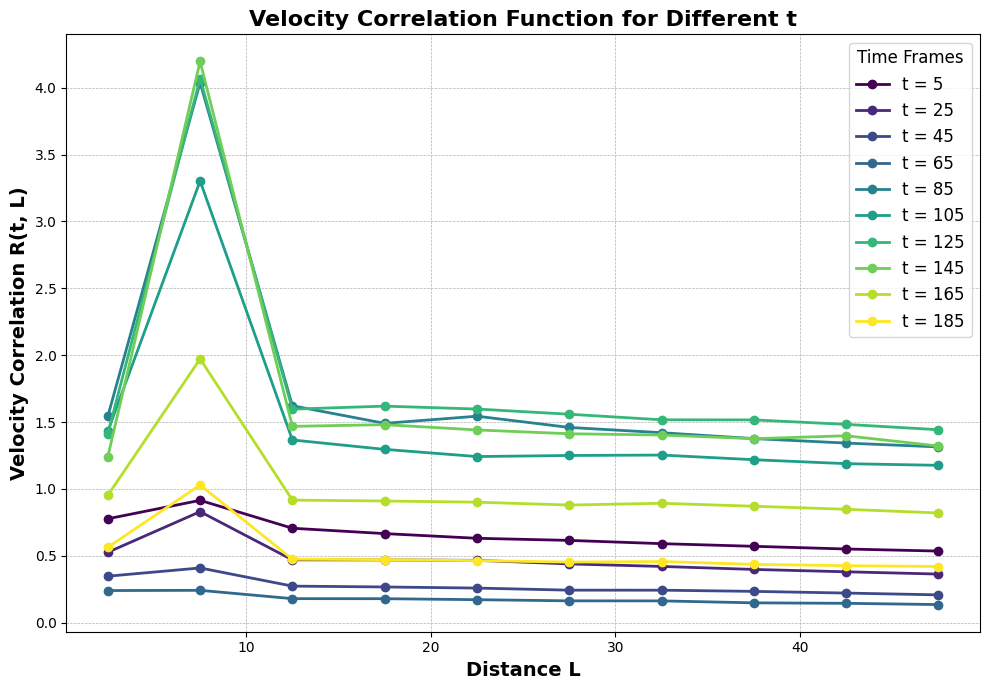

In [34]:
t_values = range(5, 201, 20)  # For example: 5, 25, 45, ..., 185
plot_velocity_correlations(df, t_values, bin_width=5, max_distance=50)

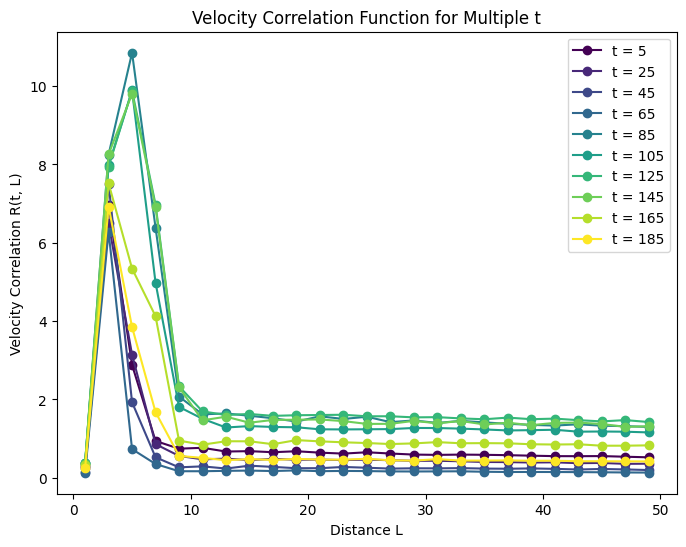

In [29]:
t_values = range(5, 201, 20)  # For example: 5, 25, 45, ..., 185
plot_velocity_correlations(df, t_values, bin_width=2, max_distance=50)

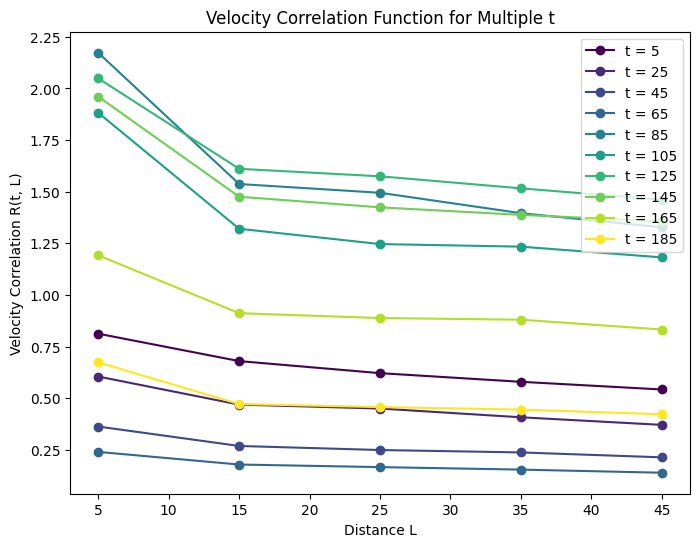

In [30]:
t_values = range(5, 201, 20)  # For example: 5, 25, 45, ..., 185
plot_velocity_correlations(df, t_values, bin_width=10, max_distance=50)